In [5]:
from ProblemiInversi import operators, solvers, utilities
import numpy as np
from numpy.linalg import svd
import matplotlib.pyplot as plt
from skimage import data

## Compressione file SVD

In [6]:
X=plt.imread("lena.bmp")

nx, ny = X.shape
rank=min(nx,ny)

U, s, Vt = svd(X, full_matrices=False)

p_arr = np.arange(1,150)

norm_A = np.linalg.norm(X)

for i in p_arr:

    S_p = np.diag(s[:i])
    A_p = U[:, :i] @ S_p @ Vt[:i, :]
    
    diff_norm = np.linalg.norm(X - A_p)
    rel_error = diff_norm / norm_A

    cp = (1/i) * rank - 1

<img src="./graphs/SVD1.png" width="1400" alt="Decompressione immagine">

<img src="./graphs/SVD_graph.png" width="1400" alt="Calcolo errore">

---
## Sfocamento dell'Immagine

In [7]:
k=5
kernel = utilities.gaussian2d_kernel(k=k, sigma=3.5)
A = operators.ConvolutionOperator(kernel)

y = A(X)

noise_level = 0.1

y_delta = y + utilities.gaussian_noise(y, noise_level=noise_level)

ER_sfocatura = utilities.rel_err(y_delta, X)
ER_sfocatura = np.round(ER_sfocatura, 4)

<img src="./graphs/sfocamento1.png" width="32%" />
<img src="./graphs/sfocamento2.png" width="32%" />
<img src="./graphs/sfocamento3.png" width="32%" />

---
## Soluzione Naive

In [8]:
cgls_solver = solvers.CGLS(A)

x0 = np.zeros_like(X)
kmax = 30
tolf = 1e-8
tolx = 1e-8

x_cgls = cgls_solver.solve(y_delta, x0, kmax, tolf, tolx)

ER_naive=np.round(utilities.rel_err(x_cgls, X), 5)

<img src="./graphs/ricostruzione_naive1.png" width="24%" />
<img src="./graphs/ricostruzione_naive2.png" width="24%" />
<img src="./graphs/ricostruzione_naive4.png" width="24%" />
<img src="./graphs/ricostruzione_naive3.png" width="24%" />

---
## Ricostruzione Tikhonov

In [9]:
def Tikhonov(A, y, lamb, y_delta, X):
    L = operators.Identity()
    M = operators.TikhonovOperator(A, L, lamb)

    ybar_delta = np.pad(y_delta, ((0, nx), (0, 0)))

    cgls_tik_solver = solvers.CGLS(M)
    x_tik = cgls_tik_solver.solve(ybar_delta, x0, kmax, tolf, tolx)

    abs_err = np.linalg.norm(x_tik - X)
    
    residual_vector = A(x_tik) - y_delta 
    res_val = np.linalg.norm(residual_vector)

    return x_tik, abs_err, res_val

lambdas = np.logspace(-5, 1, 20)

results = []

y = A(X)

for i in lambdas:
    results.append(Tikhonov(A, y, i, y_delta, X))

solutions, abs_error, residuals = zip(*results)

noise_norm = np.linalg.norm(y_delta - y)

idx_min_err = np.argmin(abs_error)
best_lambda_err = lambdas[idx_min_err]
min_error_val = abs_error[idx_min_err]

print(f"\nLambda (Minimo Errore): {best_lambda_err:.2e}")
print(f"Errore minimo: {min_error_val:.4f}")

idx_discrepancy = np.argmin(np.abs(np.array(residuals) - noise_norm))
best_lambda_discrepancy = lambdas[idx_discrepancy]

print(f"Lambda (Discrepanza): {best_lambda_discrepancy:.2e}")
print(f"Residuo al lambda discrepanza: {residuals[idx_discrepancy]:.4f}")


Lambda (Minimo Errore): 2.64e-01
Errore minimo: 8501.5438
Lambda (Discrepanza): 2.64e-01
Residuo al lambda discrepanza: 7531.3626


<img src="./graphs/graph_tikhonov1.png"/>
<img src="./graphs/graph_tikhonov2.png"/>

<img src="./graphs/ricostruzione_tikhonov1.png" width="32%" />
<img src="./graphs/ricostruzione_tikhonov2.png" width="32%" />
<img src="./graphs/ricostruzione_tikhonov3.png" width="32%" />


---
## Ricostruzione Con Total Variation


In [10]:
lambdas_tv = np.logspace(-4, 2, 20) 

errors_tv = []
solutions_tv = []

beta = 1e-3
gd_tv_solver = solvers.GDTotalVariation(A, beta=beta)

x0 = np.zeros_like(X)
kmax = 50
tolf = 1e-8
tolx = 1e-8

for lmbda in lambdas_tv:
    val, _, _ = gd_tv_solver.solve(y_delta, lmbda, x0, kmax, tolf, tolx)
    err = np.linalg.norm(val - X)
    errors_tv.append(err)
    solutions_tv.append(val)


Miglior Lambda TV: 2.64e+00
Errore Minimo TV: 4951.4752


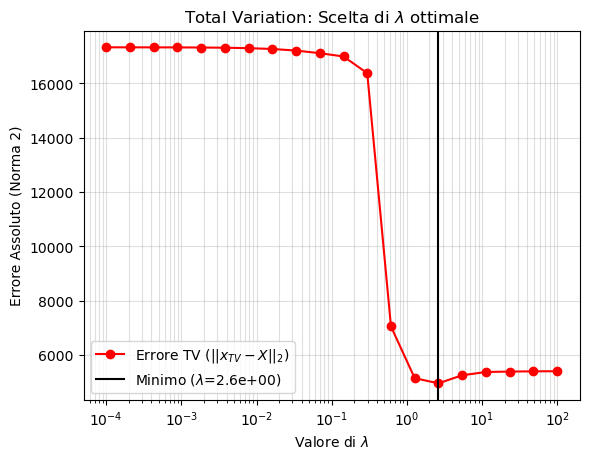

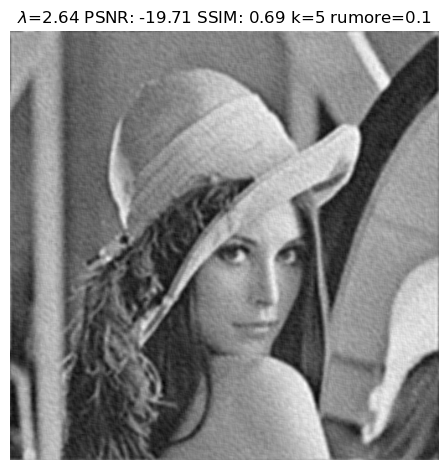

------------------------------
PSNR TV Ottimale: -19.70929289452994 dB
SSIM TV Ottimale: 0.6853745292573158


In [11]:
idx_min_tv = np.argmin(errors_tv)

best_lambda_tv = lambdas_tv[idx_min_tv]
x_best_tv = solutions_tv[idx_min_tv]
min_err_tv = errors_tv[idx_min_tv]

print(f"\nMiglior Lambda TV: {best_lambda_tv:.2e}")
print(f"Errore Minimo TV: {min_err_tv:.4f}")

ssim_x = utilities.ssim(x_best_tv, X)
psnr_x = utilities.psnr(x_best_tv, X)


plt.semilogx(lambdas_tv, errors_tv, 'r-o', label=r'Errore TV ($||x_{TV} - X||_2$)')
plt.axvline(x=best_lambda_tv, color='k', label=fr'Minimo ($\lambda$={best_lambda_tv:.1e})')
plt.xlabel(r'Valore di $\lambda$')
plt.ylabel('Errore Assoluto (Norma 2)')
plt.title(r'Total Variation: Scelta di $\lambda$ ottimale')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.4)
plt.savefig("./graphs/graph_TV3.png", dpi=300, bbox_inches='tight')
plt.show()

plt.imshow(x_best_tv, cmap="gray")
plt.axis("off")
plt.title(fr"$\lambda$={best_lambda_tv:.2f} PSNR: {psnr_x:.2f} SSIM: {ssim_x:.2f} k={k} rumore={noise_level}")

plt.tight_layout()
plt.savefig("./graphs/image_TV3.png", dpi=300, bbox_inches='tight')
plt.show()

print("-" * 30)
print(f"PSNR TV Ottimale: {psnr_x} dB")
print(f"SSIM TV Ottimale: {ssim_x}")

<img src="./graphs/image_TV1.png" width=32%/>
<img src="./graphs/image_TV2.png" width=32%/>
<img src="./graphs/image_TV3.png" width=32%/>

<img src="./graphs/graph_TV1.png" width=32%/>
<img src="./graphs/graph_TV2.png" width=32%/>
<img src="./graphs/graph_TV3.png" width=32%/>